## Exploratory Data Analysis

"Give Me Some Credit" dataset, 150,000 borrowers, 10 features plus the
target variable `SeriousDlqin2yrs` (serious delinquency of 90 days or
more within two years).

The goal of this notebook is to identify data quality problems before
any cleaning or modelling. Each finding below leads to a specific
decision implemented in `src/data.py`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("../data/cs-training.csv",index_col=0)
df.shape

(150000, 11)

## 1. Structure and missing values

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: float64(

Two columns have missing values: `MonthlyIncome` (29,731 records, 19.8%)
and `NumberOfDependents` (3,924 records, 2.6%).

The missingness in `MonthlyIncome` is not random. Borrowers with no
income recorded default at 5.61% against 6.95% for those with a known
income, so the absence of the value carries information in itself.
These two rates were computed in SQL, see `src/queries.sql`.

**Decision:** impute the missing values but keep an `income_missing`
indicator column, so the signal is preserved rather than erased by the
imputation.

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0
NumberOfTime60-89DaysPastDueNotWorse,150000.0,0.240387,4.155179,0.0,0.000000,0.000000,0.000000,98.0


Three columns show values that cannot be read at face value:
`RevolvingUtilizationOfUnsecuredLines` should be a ratio but reaches
50,708; `DebtRatio` should be a ratio but reaches 329,664; all three
delinquency counters share an identical maximum of 98.

## 2. Revolving utilization above 100%

Values above 1 are possible in practice, since interest and over limit
fees can push a balance beyond the granted credit limit. The question is
how far above 1 the values go, and whether the extreme ones carry any
risk signal.

In [4]:
(df["RevolvingUtilizationOfUnsecuredLines"]>1).sum()

np.int64(3321)

In [5]:
(df["RevolvingUtilizationOfUnsecuredLines"]>1.5).sum()

np.int64(600)

In [6]:
(df["RevolvingUtilizationOfUnsecuredLines"]>10).sum()

np.int64(241)

In [7]:
df[df["RevolvingUtilizationOfUnsecuredLines"]>10][["RevolvingUtilizationOfUnsecuredLines","MonthlyIncome","age","SeriousDlqin2yrs"]].head(10)

,RevolvingUtilizationOfUnsecuredLines,MonthlyIncome,age,SeriousDlqin2yrs
294,2340.0,8333.0,45,0
698,2066.0,6000.0,58,1
1992,1143.0,6500.0,44,1
2332,6324.0,11318.0,59,0
4279,1982.0,8000.0,33,0
4794,3746.0,2600.0,52,0
6761,941.0,5000.0,37,0
6851,8497.0,5800.0,28,0
7638,1577.0,5526.0,37,1
7775,1028.0,NaN,27,0


In [8]:
df[df["RevolvingUtilizationOfUnsecuredLines"]>10][["SeriousDlqin2yrs"]].mean()

SeriousDlqin2yrs    0.070539
dtype: float64

Of 3,321 records above 1, only 241 exceed 10, so the vast majority of
over limit cases are moderate and plausible. The default rate in the
extreme group is 7.05% against a baseline of 6.68%, which is no
meaningful difference at this sample size.

**Decision:** cap extreme values so they do not distort feature scaling.
No indicator flag is added, since the extreme values carry no signal.

## 3. DebtRatio is not always a ratio

The number of records with an implausible `DebtRatio` is close to the
number of missing values in `MonthlyIncome`. If the two overlap, the
likely explanation is that the division was never performed when income
was unknown, leaving the raw debt amount in the field.

In [9]:
(df["DebtRatio"] > 2).sum()

np.int64(31045)

In [10]:
((df["DebtRatio"] > 2) & (df["MonthlyIncome"].isna())).sum()

np.int64(27744)

In [11]:
df[df["MonthlyIncome"].isna()]["DebtRatio"].median()

np.float64(1159.0)

Of 31,045 records with `DebtRatio` above 2, some 27,744 have no income
recorded, which is 93% of all missing income cases. Among borrowers with
a known income, only 2.7% exceed 2. The median `DebtRatio` in the
missing income group is 1,159, a plausible monthly debt payment rather
than a proportion.

**Decision:** move these values into a separate `debt_amount` column and
set `DebtRatio` to missing for those rows. The two quantities are not
comparable and should not share a column.

## 4. Sentinel codes in the delinquency counters

In [12]:
df["NumberOfTimes90DaysLate"].value_counts()

NumberOfTimes90DaysLate
0     141662
1       5243
2       1555
3        667
4        291
98       264
5        131
6         80
7         38
8         21
9         19
10         8
96         5
11         5
13         4
15         2
14         2
12         2
17         1
Name: count, dtype: int64

In [13]:
((df["NumberOfTime30-59DaysPastDueNotWorse"] > 90) &
 (df["NumberOfTime60-89DaysPastDueNotWorse"] > 90) &
 (df["NumberOfTimes90DaysLate"] > 90)).sum()

np.int64(269)

The distribution declines smoothly from 0 to 17, then jumps to 264
records with a value of 98 and 5 with 96. A genuine count of 98
delinquencies would be rarer than a count of 17, not more common, so
these are sentinel codes carried over from the source system rather than
observed counts.

The same 269 rows carry a code in all three delinquency columns at once,
which rules out reading them as counts: a borrower cannot be 98 times in
the 30 to 59 day bucket and 98 times in the 90 day bucket simultaneously.

In [14]:
df[df["NumberOfTimes90DaysLate"]>90]["SeriousDlqin2yrs"].mean()

np.float64(0.5464684014869888)

These rows are not noise. Their default rate is 54.6% against a baseline
of 6.68%, roughly eight times higher, which makes them the single
riskiest group in the dataset. Dropping them would remove the strongest
risk signal available. The likely explanation is that the account left
normal servicing, through collections, charge off or bankruptcy, at
which point the source system stopped counting delinquencies and wrote a
status code instead.


**Decision:** replace 96 and 98 with missing values in all three
delinquency columns, since the true count is genuinely unknown, and add
a binary `sentinel_code` flag marking the affected rows. The flag
preserves the risk signal without inventing a delinquency count. The
column is named after what was observed in the data rather than after
the suspected cause, which remains an inference.

## 5. Number of dependents

In [15]:
(df["NumberOfDependents"].value_counts()).sort_index()

NumberOfDependents
0.0     86902
1.0     26316
2.0     19522
3.0      9483
4.0      2862
5.0       746
6.0       158
7.0        51
8.0        24
9.0         5
10.0        5
13.0        1
20.0        1
Name: count, dtype: int64

In [16]:
df[df["NumberOfDependents"].isna()]["SeriousDlqin2yrs"].mean()

np.float64(0.04561671763506626)

In [17]:
df[~df["NumberOfDependents"].isna()]["SeriousDlqin2yrs"].mean()

np.float64(0.0674101152824557)

In [18]:
df.groupby("NumberOfDependents")["SeriousDlqin2yrs"].agg(["mean","count"])

,mean,count
NumberOfDependents,,
0.0,0.058629,86902
1.0,0.073529,26316
2.0,0.081139,19522
3.0,0.088263,9483
4.0,0.103774,2862
5.0,0.091153,746
6.0,0.151899,158
7.0,0.098039,51
8.0,0.083333,24



The distribution declines smoothly from 0 to 10, with single records at
13 and 20 and no clustering in the upper range, so unlike the
delinquency counters this column carries no sentinel codes.

Of 3,924 missing values, the pattern repeats what was found for
`MonthlyIncome`: borrowers with no value recorded default at 4.56%
against 6.74% for those with one, so the absence is not random. Default
rate then rises monotonically across the populated range, from 5.86% at
zero dependents to 10.38% at four. Above four the rate becomes erratic
and group sizes collapse to a handful of records.

**Decision:** impute with 0, both the median and the mode of an integer
count, and add a `dependents_missing` flag so the informative absence is
not buried by the imputation. Values of 5 and above are collapsed into a
single category during feature construction.

## 6. Figures

In [19]:
age_group = pd.cut(df["age"],bins=[17,25,35,45,55,65,120],labels=["18-25","26-35","36-45","46-55","56-65","66+"])

In [20]:
age_stats=df.groupby(age_group)["SeriousDlqin2yrs"].agg(["mean","count"])

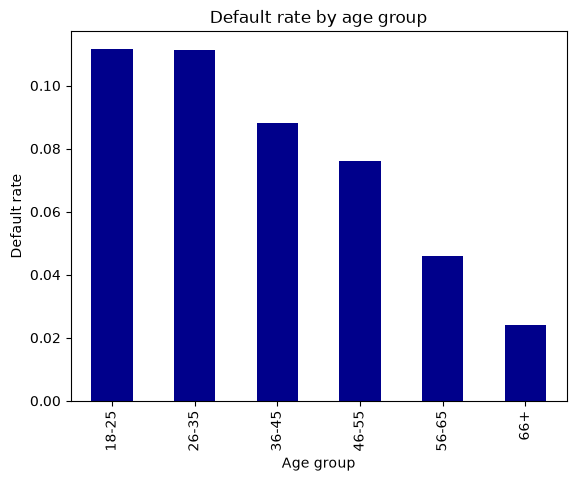

In [21]:
age_stats["mean"].plot(kind="bar",color="darkblue")
plt.title("Default rate by age group")
plt.xlabel("Age group")
plt.ylabel("Default rate")
plt.savefig("../reports/figures/default_rate_by_age.png",dpi=150,bbox_inches="tight")
plt.show()

In [22]:
dep_stats=df.groupby("NumberOfDependents")["SeriousDlqin2yrs"].agg(["mean","count"])

In [23]:
dep_stats.loc[0:4]

,mean,count
NumberOfDependents,,
0.0,0.058629,86902
1.0,0.073529,26316
2.0,0.081139,19522
3.0,0.088263,9483
4.0,0.103774,2862


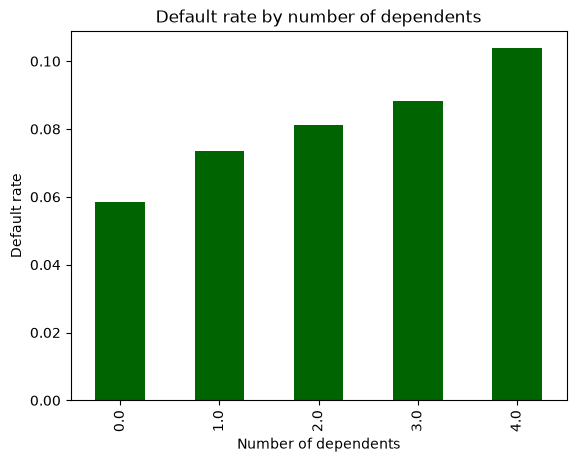

In [24]:
dep_stats.loc[0:4]["mean"].plot(kind="bar",color="darkgreen")
plt.title("Default rate by number of dependents")
plt.xlabel("Number of dependents")
plt.ylabel("Default rate")
plt.savefig("../reports/figures/default_rate_by_dependents.png",dpi=150,bbox_inches="tight")
plt.show()

In [25]:
sentinel_stats=df.groupby(df["NumberOfTimes90DaysLate"]>90)["SeriousDlqin2yrs"].agg(["mean","count"]).rename({False: "Normal records",True: "Sentinel code"})

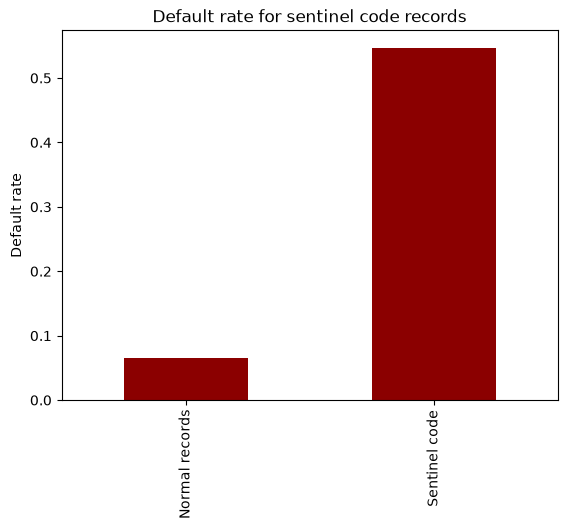

In [26]:
sentinel_stats["mean"].plot(kind="bar",color="darkred")
plt.title("Default rate for sentinel code records")
plt.xlabel("")
plt.ylabel("Default rate")
plt.savefig("../reports/figures/default_rate_sentinel_codes.png",dpi=150,bbox_inches="tight")
plt.show()

Three figures are saved to `reports/figures/`: default rate by age
group, by number of dependents, and for records carrying a sentinel
code. Age and dependents are shown over their populated ranges only,
with the sparse tail of the dependents distribution excluded, since
rates computed from a handful of records are not interpretable.

`DebtRatio` is not plotted. The two quantities sharing that column
differ by three orders of magnitude, so any single axis would hide one
of them, and the tables in section 3 make the point more directly.